In [ ]:
# For local development, skip Google Colab imports
# Uncomment below only if running in Google Colab:
# from google.colab import drive
# drive.mount('/content/drive')

print("Environment configured for local development")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
import os
import shutil

# For local development: Update these paths as needed
zip_path = "archive (14).zip"  # Put your zip file in the project folder
extract_path = "liveness_data"

# Create directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Extract only if not already extracted
if not os.path.exists(os.path.join(extract_path, 'train')) or not os.path.exists(os.path.join(extract_path, 'val')):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Extracted to {extract_path}")
else:
    print(f"Data already extracted in {extract_path}")

# Display structure
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files[:3]:  # Show first 3 files per directory
        print(f'{subindent}{file}')

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create data generators for training and validation
IMG_SIZE = 128
BATCH_SIZE = 32

# For training data - with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# For validation data - only rescaling
val_datagen = ImageDataGenerator(rescale=1./255)

# Load training data from directory structure
train_data = train_datagen.flow_from_directory(
    os.path.join(extract_path, 'train'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'  # Binary classification: real/fake
)

# Load validation data from directory structure
val_data = val_datagen.flow_from_directory(
    os.path.join(extract_path, 'val'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

print("Data loaded successfully!")
print(f"Training samples: {train_data.samples}")
print(f"Validation samples: {val_data.samples}")

In [ ]:
# Load test data if test directory exists
test_data = None
test_data_path = os.path.join(extract_path, 'test')

if os.path.exists(test_data_path):
    test_datagen = ImageDataGenerator(rescale=1./255)
    test_data = test_datagen.flow_from_directory(
        test_data_path,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )
    print(f"Test data loaded successfully!")
    print(f"Test samples: {test_data.samples}")
else:
    print(f"Note: Test data directory not found at {test_data_path}")
    print("You can still train and validate the model.")

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,568,321 (5.98 MB)

 Trainable params: 1,568,321 (5.98 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 384s 1s/step - accuracy: 0.9902 - loss: 0.0296 - val_accuracy: 0.9912 - val_loss: 0.0285
Epoch 2/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 382s 1s/step - accuracy: 0.9884 - loss: 0.0359 - val_accuracy: 0.9978 - val_loss: 0.0161
Epoch 3/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 379s 1s/step - accuracy: 0.9923 - loss: 0.0202 - val_accuracy: 1.0000 - val_loss: 0.0025
Epoch 4/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 380s 1s/step - accuracy: 0.9926 - loss: 0.0238 - val_accuracy: 0.9978 - val_loss: 0.0056
Epoch 5/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 377s 1s/step - accuracy: 0.9917 - loss: 0.0266 - val_accuracy: 0.9934 - val_loss: 0.0226
Epoch 6/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 382s 1s/step - accuracy: 0.9938 - loss: 0.0257 - val_accuracy: 0.9846 - val_loss: 0.0412
Epoch 7/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 377s 1s/step - accuracy: 0.9928 - loss: 0.0245 - val_accuracy: 0.9989 - val_loss: 0.0016
Epoch 8/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 388s 2s/step - accuracy: 0.9962 - loss: 0.0121 - val_accu

In [ ]:
if test_data is not None:
    loss, acc = model.evaluate(test_data)
    print(f"Test Accuracy: {acc:.4f}")
    print(f"Test Loss: {loss:.4f}")
else:
    print("Test data not available")
    print("Create a 'test' directory in liveness_data/ with subdirectories for each class")

72/72 ━━━━━━━━━━━━━━━━━━━━ 29s 404ms/step - accuracy: 0.9991 - loss: 0.0056
Test Accuracy: 0.9991212487220764


In [ ]:
# Local alternative to Colab's take_photo - loads an image file instead
import cv2
import os
from pathlib import Path

def take_photo(filename='photo.jpg', quality=0.95, button_text='Capture'):
    """
    For local development, load an image file instead of capturing from webcam.
    Place your test image in the project directory with the filename specified.
    """
    if not os.path.exists(filename):
        raise FileNotFoundError(
            f"Image file '{filename}' not found. "
            f"Please provide a test image in the project directory."
        )
    return filename

# Test: Load an image if it exists
try:
    photo_path = take_photo('photo.jpg')
    print(f"Loaded image: {photo_path}")
    
    # Display using matplotlib (works locally)
    import matplotlib.pyplot as plt
    img = cv2.imread(photo_path)
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(8, 6))
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.title('Loaded Photo')
        plt.tight_layout()
        plt.show()
except FileNotFoundError as e:
    print(f"Note: {e}")

In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf

IMG_SIZE = 128
MODEL_PATH = "cnn_liveness_model.keras"  # Local path
IMAGE_PATH = "photo.jpg"  # Local path

print("Model exists:", os.path.exists(MODEL_PATH))
print("Image exists:", os.path.exists(IMAGE_PATH))

if os.path.exists(MODEL_PATH):
    model = tf.keras.models.load_model(MODEL_PATH)

    if os.path.exists(IMAGE_PATH):
        img = cv2.imread(IMAGE_PATH)

        if img is None:
            raise ValueError("Error in reading photo")

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img.astype("float32") / 255.0
        img = np.expand_dims(img, axis=0)

        pred = model.predict(img, verbose=0)[0][0]
        print("Raw prediction:", pred)

        if pred >= 0.5:
            print(f"RESULT: FAKE / SPOOF | score={pred:.4f}")
        else:
            print(f"RESULT: REAL / LIVE | score={pred:.4f}")
    else:
        print(f"Image not found at {IMAGE_PATH}")
else:
    print(f"Model not found at {MODEL_PATH}. Train the model first.")

Model exists: True
Image exists: True
Raw prediction: 5.1207862e-05
RESULT: REAL / LIVE | score=0.0001


# **المرحله الثانية **

In [ ]:
!pip -q install easyocr opencv-python-headless imutils pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 16.5 MB/s eta 0:00:00


In [ ]:
import cv2
import numpy as np
import pandas as pd
import easyocr
import matplotlib.pyplot as plt
from base64 import b64decode
import re
import os

print("All imports successful")

<IPython.core.display.Javascript object>

saved: card.jpg


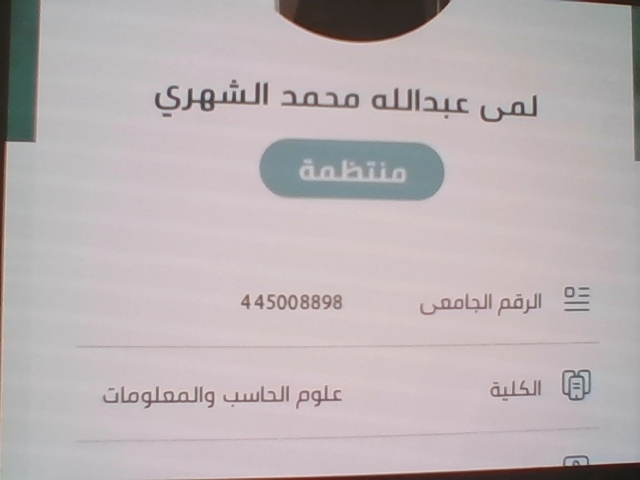

In [ ]:
# Local alternative for card capture - loads an image file
import cv2
import matplotlib.pyplot as plt
import os

def take_photo(filename='card.jpg', quality=0.95, button_text='Capture Card'):
    """
    For local development, load an image file instead of capturing from webcam.
    Place your card image in the project directory with the filename specified.
    """
    if not os.path.exists(filename):
        raise FileNotFoundError(
            f"Image file '{filename}' not found. "
            f"Please provide a test image in the project directory."
        )
    return filename

# Test: Load the card image if it exists
try:
    card_path = take_photo('card.jpg', button_text='Capture University Card')
    print(f"Loaded card image: {card_path}")
    
    # Display using matplotlib
    img = cv2.imread(card_path)
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 6))
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.title('University Card')
        plt.tight_layout()
        plt.show()
except FileNotFoundError as e:
    print(f"Note: {e}")

In [ ]:
import cv2
import numpy as np

def detect_and_crop_bright_region(image_path, save_path='cropped_card.jpg', debug_path='debug_bright_mask.jpg'):
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError("Error in reading")

    original = image.copy()
    h, w = image.shape[:2]

    # 1) convert it to gray
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # 2) blur minimizing
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # 3) threshold finding light spots
    _, thresh = cv2.threshold(blurred, 170, 255, cv2.THRESH_BINARY)

    # 4) cleaning
    kernel = np.ones((7, 7), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)

    # Mask
    cv2.imwrite(debug_path, thresh)

    # 5) contor
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        cv2.imwrite(save_path, original)
        return save_path, False

    # 6) lighter spot in image
    largest = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(largest)

    # fail if spot too small
    if area < 0.05 * (h * w):
        cv2.imwrite(save_path, original)
        return save_path, False

    # 7)  bounding rect
    x, y, bw, bh = cv2.boundingRect(largest)

    # 8) padding
    pad_x = int(0.03 * bw)
    pad_y = int(0.03 * bh)

    x1 = max(0, x - pad_x)
    y1 = max(0, y - pad_y)
    x2 = min(w, x + bw + pad_x)
    y2 = min(h, y + bh + pad_y)

    cropped = original[y1:y2, x1:x2]

    cv2.imwrite(save_path, cropped)
    return save_path, True

bright region detected: True


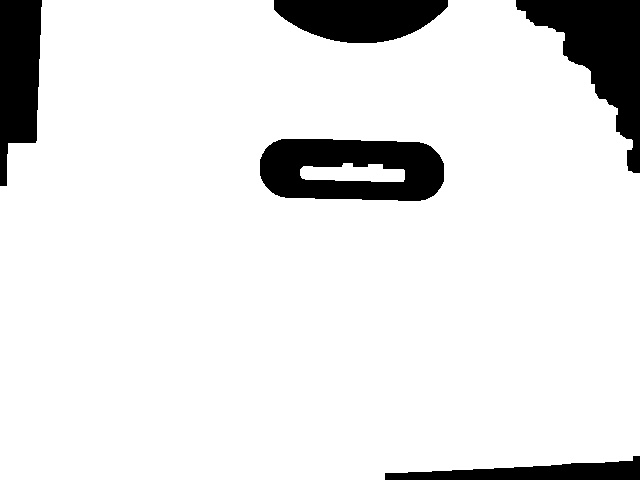

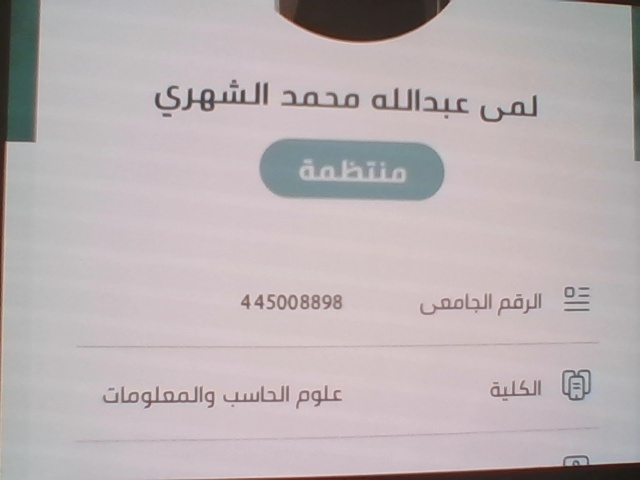

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

cropped_path, found_card = detect_and_crop_bright_region(
    'card.jpg',
    'cropped_card.jpg',
    'debug_bright_mask.jpg'
)

print("bright region detected:", found_card)

# Display images using matplotlib
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

if os.path.exists('debug_bright_mask.jpg'):
    mask_img = cv2.imread('debug_bright_mask.jpg', cv2.IMREAD_GRAYSCALE)
    axes[0].imshow(mask_img, cmap='gray')
    axes[0].set_title('Bright Region Mask')
    axes[0].axis('off')

if os.path.exists(cropped_path):
    cropped_img = cv2.imread(cropped_path)
    if cropped_img is not None:
        cropped_img_rgb = cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB)
        axes[1].imshow(cropped_img_rgb)
        axes[1].set_title('Cropped Card')
        axes[1].axis('off')

plt.tight_layout()
plt.show()

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

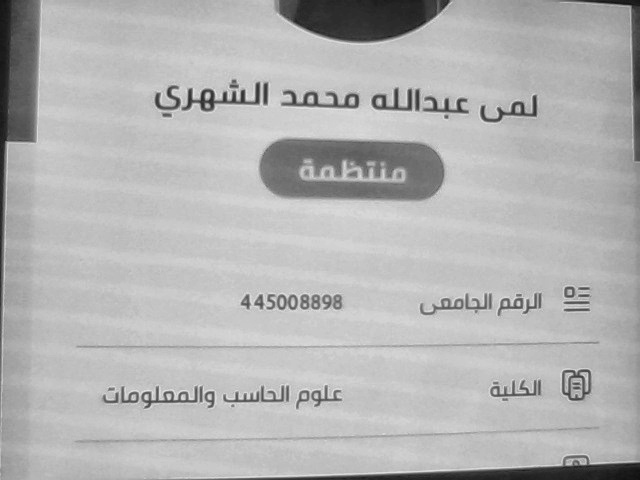

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Student ID: 445008898
Confidence: 1.000


In [ ]:
import cv2
import re
import easyocr
import matplotlib.pyplot as plt
import os

def preprocess_for_ocr(image_path):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Error in reading")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)

    cv2.imwrite("ocr_enhanced.jpg", enhanced)
    return "ocr_enhanced.jpg"


reader = easyocr.Reader(['ar', 'en'], gpu=False)

def run_ocr(image_path):
    return reader.readtext(image_path, detail=1, paragraph=False)


def extract_student_id_with_confidence(ocr_results):
    for bbox, text, conf in ocr_results:
        cleaned_text = str(text).strip()
        digits_only = re.sub(r"\D", "", cleaned_text)

        if len(digits_only) == 9:
            return digits_only, conf

    return None, None


processed_path = preprocess_for_ocr(cropped_path)

# Display using matplotlib
if os.path.exists(processed_path):
    img = cv2.imread(processed_path, cv2.IMREAD_GRAYSCALE)
    plt.figure(figsize=(10, 8))
    plt.imshow(img, cmap='gray')
    plt.title('OCR Enhanced Image')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

ocr_results = run_ocr(processed_path)

student_id, conf = extract_student_id_with_confidence(ocr_results)

if student_id is not None:
    print(f"Student ID: {student_id}")
    print(f"Confidence: {conf:.3f}")
else:
    print("No student ID found")

student_id: 445008898
name: Lama Abdullah Mohammed Alshehri
major:  Artificial Intelligence
saved to: /content/db_face.jpg


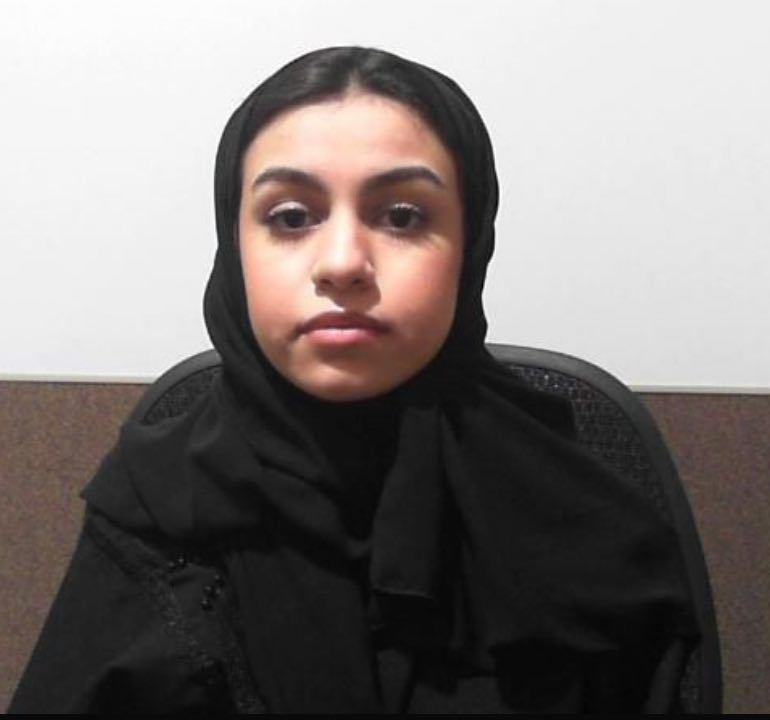

In [ ]:
import sqlite3
import matplotlib.pyplot as plt
import os
import cv2

processed_path = preprocess_for_ocr(cropped_path)
ocr_results = run_ocr(processed_path)
student_id, conf = extract_student_id_with_confidence(ocr_results)

if student_id is None:
    print("No student ID found")
else:
    # Update database path to local location
    DB_PATH = "student_face_database.sqlite"
    DB_FACE_PATH = "db_face.jpg"
    
    if not os.path.exists(DB_PATH):
        print(f"Database not found at {DB_PATH}")
    else:
        conn = sqlite3.connect(DB_PATH)
        cursor = conn.cursor()

        cursor.execute("SELECT * FROM students WHERE student_id = ?", (student_id,))
        student = cursor.fetchone()

        if student is None:
            print("Student is not in the database")
        else:
            print("student_id:", student[0])
            print("name:", student[1])
            print("major:", student[2])

            image_blob = student[6]
            
            with open(DB_FACE_PATH, "wb") as f:
                f.write(image_blob)

            print("saved to:", DB_FACE_PATH)
            
            # Display using matplotlib
            if os.path.exists(DB_FACE_PATH):
                img = cv2.imread(DB_FACE_PATH)
                if img is not None:
                    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    plt.figure(figsize=(8, 6))
                    plt.imshow(img_rgb)
                    plt.title(f"Database Face - {student[1]}")
                    plt.axis('off')
                    plt.tight_layout()
                    plt.show()

        conn.close()

# **ترتيب وتوثيق النتائج**

In [ ]:
# Updated paths for local development
BASE_DIR = "."
SELFIE_PATH = f"{BASE_DIR}/photo.jpg"
CARD_PATH = f"{BASE_DIR}/card.jpg"
MODEL_PATH = f"{BASE_DIR}/cnn_liveness_model.keras"
DB_PATH = f"{BASE_DIR}/student_face_database.sqlite"
DB_FACE_PATH = f"{BASE_DIR}/db_face.jpg"
CROPPED_CARD_PATH = f"{BASE_DIR}/cropped_card.jpg"
DEBUG_MASK_PATH = f"{BASE_DIR}/debug_bright_mask.jpg"

LOG_DIR = f"{BASE_DIR}/logs"
CSV_LOG_PATH = f"{LOG_DIR}/verification_logs.csv"
APP_LOG_PATH = f"{LOG_DIR}/app.log"
AUDIT_DB_PATH = f"{LOG_DIR}/verification_audit.sqlite"

print("Paths configured for local development")

In [ ]:
import os
import csv
import uuid
import sqlite3
import logging
from datetime import datetime

os.makedirs(LOG_DIR, exist_ok=True)

logger = logging.getLogger("verification_logger")
logger.setLevel(logging.INFO)

if not logger.handlers:
    file_handler = logging.FileHandler(APP_LOG_PATH, encoding="utf-8")
    formatter = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
    file_handler.setFormatter(formatter)
    logger.addHandler(file_handler)

In [ ]:
def initialize_csv_log(csv_path=CSV_LOG_PATH):
    if not os.path.exists(csv_path):
        with open(csv_path, "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow([
                "request_id",
                "timestamp",
                "stage",
                "status",
                "student_id",
                "student_name",
                "similarity",
                "message",
                "error_message"
            ])


def initialize_audit_db(db_path=AUDIT_DB_PATH):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()

    cursor.execute("""
        CREATE TABLE IF NOT EXISTS verification_logs (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            request_id TEXT,
            timestamp TEXT,
            stage TEXT,
            status TEXT,
            student_id TEXT,
            student_name TEXT,
            similarity REAL,
            message TEXT,
            error_message TEXT
        )
    """)

    conn.commit()
    conn.close()


def save_log_to_csv(
    request_id,
    timestamp,
    stage,
    status,
    student_id="",
    student_name="",
    similarity="",
    message="",
    error_message="",
    csv_path=CSV_LOG_PATH
):
    with open(csv_path, "a", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow([
            request_id,
            timestamp,
            stage,
            status,
            student_id,
            student_name,
            similarity,
            message,
            error_message
        ])


def save_log_to_db(
    request_id,
    timestamp,
    stage,
    status,
    student_id="",
    student_name="",
    similarity=None,
    message="",
    error_message="",
    db_path=AUDIT_DB_PATH
):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()

    cursor.execute("""
        INSERT INTO verification_logs (
            request_id,
            timestamp,
            stage,
            status,
            student_id,
            student_name,
            similarity,
            message,
            error_message
        )
        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
    """, (
        request_id,
        timestamp,
        stage,
        status,
        student_id,
        student_name,
        similarity,
        message,
        error_message
    ))

    conn.commit()
    conn.close()


def log_event(
    request_id,
    stage,
    status,
    student_id="",
    student_name="",
    similarity=None,
    message="",
    error_message=""
):
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    logger.info(
        f"request_id={request_id} | stage={stage} | status={status} | "
        f"student_id={student_id} | student_name={student_name} | "
        f"similarity={similarity} | message={message} | error={error_message}"
    )

    save_log_to_csv(
        request_id=request_id,
        timestamp=timestamp,
        stage=stage,
        status=status,
        student_id=student_id,
        student_name=student_name,
        similarity=similarity if similarity is not None else "",
        message=message,
        error_message=error_message
    )

    save_log_to_db(
        request_id=request_id,
        timestamp=timestamp,
        stage=stage,
        status=status,
        student_id=student_id,
        student_name=student_name,
        similarity=similarity,
        message=message,
        error_message=error_message
    )

In [ ]:
initialize_csv_log()
initialize_audit_db()

# **المرحلة الاخيرة**

# نموذج ديب فيس للمقارنه

In [ ]:
!pip -q install deepface

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 51.1 MB/s eta 0:00:00


In [ ]:
from deepface import DeepFace
import os

# Use local paths
selfie_path = "photo.jpg"
db_face_path = "db_face.jpg"

print("selfie exists:", os.path.exists(selfie_path))
print("db face exists:", os.path.exists(db_face_path))

if os.path.exists(selfie_path) and os.path.exists(db_face_path):
    try:
        result = DeepFace.verify(
            img1_path=selfie_path,
            img2_path=db_face_path,
            model_name="Facenet512",
            detector_backend="opencv",
            enforce_detection=True
        )

        print(result)

        if result["verified"]:
            print("MATCH")
        else:
            print("NO MATCH")
    except Exception as e:
        print(f"Verification error: {e}")
else:
    print("Required image files not found")

selfie exists: True
db face exists: True
{'verified': False, 'distance': 0.347961, 'threshold': 0.3, 'confidence': 34.33, 'model': 'Facenet512', 'detector_backend': 'opencv', 'similarity_metric': 'cosine', 'facial_areas': {'img1': {'x': 160, 'y': 200, 'w': 234, 'h': 234, 'left_eye': (320, 291), 'right_eye': (230, 290)}, 'img2': {'x': 198, 'y': 98, 'w': 295, 'h': 295, 'left_eye': None, 'right_eye': None}}, 'time': 2.8}
NO MATCH


# نموذج انسايت فيس للمقارنة

In [ ]:
!pip -q install insightface onnxruntime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 8.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 70.0 MB/s eta 0:00:00


In [ ]:
import cv2
import numpy as np
import os
from insightface.app import FaceAnalysis

# Use local paths
img1_path = "photo.jpg"
img2_path = "db_face.jpg"

print(f"Image 1 exists: {os.path.exists(img1_path)}")
print(f"Image 2 exists: {os.path.exists(img2_path)}")

if os.path.exists(img1_path) and os.path.exists(img2_path):
    try:
        app = FaceAnalysis(name='buffalo_l')
        app.prepare(ctx_id=0)

        img1 = cv2.imread(img1_path)
        img2 = cv2.imread(img2_path)

        # Convert to RGB
        img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
        img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

        faces1 = app.get(img1)
        faces2 = app.get(img2)

        if len(faces1) == 0 or len(faces2) == 0:
            print("Faces not detected in one or both images")
        else:
            emb1 = faces1[0].embedding
            emb2 = faces2[0].embedding

            similarity = np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))

            print(f"Similarity: {similarity:.4f}")

            if similarity > 0.5:
                print("MATCH")
            else:
                print("NO MATCH")
    except Exception as e:
        print(f"Face comparison error: {e}")
else:
    print("Required image files not found")

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
Similarity: 

# **pipline النهائي شامل الترتيب والتوثيق**

In [ ]:
import os
import cv2
import sqlite3
import numpy as np
import tensorflow as tf
from insightface.app import FaceAnalysis
import time

def run_interactive_pipeline():
    """
    Local version of the verification pipeline.
    Requires test images (photo.jpg, card.jpg) to be present in the project directory.
    """
    start_time = time.time()
    
    print("Starting verification pipeline...")
    
    # Check for required files
    if not os.path.exists("photo.jpg"):
        print("ERROR: photo.jpg not found")
        return "fail", round(time.time() - start_time, 2)
    
    if not os.path.exists("card.jpg"):
        print("ERROR: card.jpg not found")
        return "fail", round(time.time() - start_time, 2)
    
    if not os.path.exists(MODEL_PATH):
        print(f"ERROR: Model not found at {MODEL_PATH}")
        return "fail", round(time.time() - start_time, 2)

    # Step 2: Liveness check
    print("Step 1: Liveness check...")
    model = tf.keras.models.load_model(MODEL_PATH)

    img = cv2.imread("photo.jpg")
    if img is None:
        print("ERROR: Could not read photo.jpg")
        return "fail", round(time.time() - start_time, 2)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128, 128))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img, verbose=0)[0][0]
    print(f"Liveness score: {pred:.4f}")

    if pred >= 0.5:
        print("ERROR: Spoof/Fake image detected")
        return "fail", round(time.time() - start_time, 2)

    # Step 3: Card processing and OCR
    print("Step 2: Processing university card...")
    cropped_path, found_card = detect_and_crop_bright_region(
        "card.jpg",
        CROPPED_CARD_PATH,
        DEBUG_MASK_PATH
    )

    if not found_card:
        print("ERROR: Could not detect card region")
        return "fail", round(time.time() - start_time, 2)

    # Step 4: OCR and student ID extraction
    print("Step 3: Extracting student ID via OCR...")
    processed_path = preprocess_for_ocr(cropped_path)
    ocr_results = run_ocr(processed_path)
    student_id, conf = extract_student_id_with_confidence(ocr_results)

    if student_id is None:
        print("ERROR: Could not extract student ID")
        return "fail", round(time.time() - start_time, 2)

    print(f"Extracted ID: {student_id}")

    # Step 5: Database lookup
    print("Step 4: Verifying student in database...")
    if not os.path.exists(DB_PATH):
        print(f"ERROR: Database not found at {DB_PATH}")
        return "fail", round(time.time() - start_time, 2)
    
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()

    cursor.execute("SELECT * FROM students WHERE student_id = ?", (student_id,))
    student = cursor.fetchone()

    if student is None:
        conn.close()
        print("ERROR: Student not found in database")
        return "fail", round(time.time() - start_time, 2)

    student_name = student[1]
    image_blob = student[6]

    # Save DB face image
    with open(DB_FACE_PATH, "wb") as f:
        f.write(image_blob)

    conn.close()
    
    print(f"Student: {student_name}")

    # Step 6: Face verification
    print("Step 5: Verifying face match...")
    img1 = cv2.imread("photo.jpg")
    img2 = cv2.imread(DB_FACE_PATH)

    if img1 is None or img2 is None:
        print("ERROR: Could not read face images")
        return "fail", round(time.time() - start_time, 2)

    img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

    try:
        app = FaceAnalysis(name="buffalo_l")
        app.prepare(ctx_id=0)

        faces1 = app.get(img1)
        faces2 = app.get(img2)

        if len(faces1) == 0 or len(faces2) == 0:
            print("ERROR: No faces detected")
            return "fail", round(time.time() - start_time, 2)

        emb1 = faces1[0].embedding
        emb2 = faces2[0].embedding

        similarity = np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))

        print(f"Face similarity: {similarity:.4f}")

        execution_time = round(time.time() - start_time, 2)

        if similarity > 0.5:
            print(f"SUCCESS: Welcome, {student_name}!")
            return "success", execution_time
        else:
            print("ERROR: Faces do not match")
            return "fail", execution_time
    except Exception as e:
        print(f"ERROR: Face verification failed - {e}")
        return "fail", round(time.time() - start_time, 2)

# **performence**

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = []

def add_result(case_id, expected, predicted, execution_time, notes):
    results.append({
        "case_id": case_id,
        "expected": expected,
        "predicted": predicted,
        "execution_time": execution_time,
        "notes": notes
    })

def show_performance():
    df = pd.DataFrame(results)
    display(df)

    y_true = df["expected"]
    y_pred = df["predicted"]

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label="success")
    recall = recall_score(y_true, y_pred, pos_label="success")
    f1 = f1_score(y_true, y_pred, pos_label="success")
    avg_time = df["execution_time"].mean()

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1-score :", round(f1, 4))
    print("Average Execution Time:", round(avg_time, 2), "seconds")

In [54]:
predicted, exec_time = run_interactive_pipeline()
print(predicted, exec_time)

fail 142.97


suppose to success

In [47]:
add_result(
    case_id="TC01",
    expected="success",
    predicted=predicted,
    execution_time=exec_time,
    notes="Real selfie, valid card, matching face"
)

suppose to fail

In [50]:
add_result(
    case_id="TC02",
    expected="fail",
    predicted=predicted,
    execution_time=exec_time,
    notes="Fake selfie"
)

In [53]:
add_result(
    case_id="TC03",
    expected="success",
    predicted=predicted,
    execution_time=exec_time,
    notes="Real selfie, valid card, matching face"
)

In [55]:
add_result(
    case_id="TC04",
    expected="fail",
    predicted=predicted,
    execution_time=exec_time,
    notes="fake selfie"
)

show performence

In [56]:
show_performance()

,case_id,expected,predicted,execution_time,notes
0,TC01,success,success,56.21,"Real selfie, valid card, matching face"
1,TC02,fail,fail,52.21,Fake selfie
2,TC01,success,success,67.79,"Real selfie, valid card, matching face"
3,TC02,fail,fail,12.09,Fake selfie
4,TC03,success,success,82.42,"Real selfie, valid card, matching face"
5,TC04,fail,fail,142.97,fake selfie


Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0
Average Execution Time: 68.95 seconds
